<a href="https://colab.research.google.com/github/nitya-balaji/digit-recognizer-cnn/blob/main/digit_recognizer_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#convert MNIST image files into 4D tensor (# of images, height, width, colour channel)
transform = transforms.ToTensor()

In [ ]:
#train data
train_data = datasets.MNIST(root="/cnn_data", train=True, download=True, transform=transform)

In [ ]:
#test data
test_data = datasets.MNIST(root="/cnn_data", train=False, download=True, transform=transform)

In [ ]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
#create a small batch size of 10 for images
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [ ]:
#define CNN model (for 1 image)
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [ ]:
for i, (X_train, y_train) in enumerate(train_data):
  break

In [ ]:
X_train.shape #one 2D image

torch.Size([1, 28, 28])

In [ ]:
x = X_train.view(1,1,28,28) #converting to a 4D image

In [ ]:
#first convolution
x = F.relu(conv1(x))

In [ ]:
x.shape #26 x 26 due to padding is off (so irrelevant pixels dropped bc digit is in the middle - nothing is on the outer pixel layer)

torch.Size([1, 6, 26, 26])

In [ ]:
#pass through pooling layer
x = F.max_pool2d(x, 2, 2)
x.shape #26/2 = 13 x 13

torch.Size([1, 6, 13, 13])

In [ ]:
#second convolutional layer (x is still the same)
x = F.relu(conv2(x))
x.shape #no padding on 13x13 so lose 2 pixels around outside of image

torch.Size([1, 16, 11, 11])

In [ ]:
#pooling
x = F.max_pool2d(x,2,2)
x.shape #11/2 = 5 x 5 (rounded down)

torch.Size([1, 16, 5, 5])

In [ ]:
#model class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    #define convoluational layers
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    #define fully connected layers
    self.layer1 = nn.Linear(5*5*16,120)
    self.layer2 = nn.Linear(120, 84)
    self.out = nn.Linear(84,10)

  def forward(self, X):
    x = F.relu(self.conv1(X)) #first pass
    x = F.max_pool2d(x,2,2)
    x = F.relu(self.conv2(x)) #second pass
    x = F.max_pool2d(x,2,2)

    #re-view data to flatten it out
    x = x.view(-1,16*5*5) #-1 to vary batch size

    #fully connected layers
    x = F.relu(self.layer1(x))
    x = F.relu(self.layer2(x))
    x = self.out(x)
    return F.log_softmax(x, dim=1)



In [ ]:
torch.manual_seed(42)
model=ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (layer1): Linear(in_features=400, out_features=120, bias=True)
  (layer2): Linear(in_features=120, out_features=84, bias=True)
  (out): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
#loss function optimizer
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
import time
start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
  train_corr = 0
  test_corr = 0
  #train
  for b, (X_train, y_train) in enumerate(train_loader):
    b+= 1 #start batches at 1
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    predicted = torch.max(y_pred.data, 1)[1] #add up # of correct predictions (Indexed off the first point)
    batch_corr = (predicted == y_train).sum() #how many we got correct from this batch
    train_corr += batch_corr

    #backprop/update params
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if b % 600 == 0:
      print(f"Epoch: {i}, loss: {loss.item()}, batch: {b}")
  train_losses.append(loss)
  train_correct.append(train_corr)

#test
  with torch.no_grad():
    for b, (X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1]
      test_corr += (predicted == y_test).sum()
  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(test_corr)

current_time = time.time()
total_time = current_time - start_time
print(f"Training took: {total_time/60} mins.")

Epoch: 0, loss: 0.040556274354457855, batch: 600
Epoch: 0, loss: 0.08253474533557892, batch: 1200
Epoch: 0, loss: 0.3647049069404602, batch: 1800
Epoch: 0, loss: 0.018250251188874245, batch: 2400
Epoch: 0, loss: 0.008067040704190731, batch: 3000
Epoch: 0, loss: 0.001166942878626287, batch: 3600
Epoch: 0, loss: 0.5255253911018372, batch: 4200
Epoch: 0, loss: 0.03260819613933563, batch: 4800
Epoch: 0, loss: 0.007468158844858408, batch: 5400
Epoch: 0, loss: 0.03889675810933113, batch: 6000
Epoch: 1, loss: 0.032828204333782196, batch: 600
Epoch: 1, loss: 0.04554177075624466, batch: 1200
Epoch: 1, loss: 0.005784796085208654, batch: 1800
Epoch: 1, loss: 0.02235613949596882, batch: 2400
Epoch: 1, loss: 0.21643038094043732, batch: 3000
Epoch: 1, loss: 0.00501451687887311, batch: 3600
Epoch: 1, loss: 0.00045869071618653834, batch: 4200
Epoch: 1, loss: 0.0019295118981972337, batch: 4800
Epoch: 1, loss: 0.0008596166153438389, batch: 5400
Epoch: 1, loss: 0.08304359018802643, batch: 6000
Epoch: 2, 

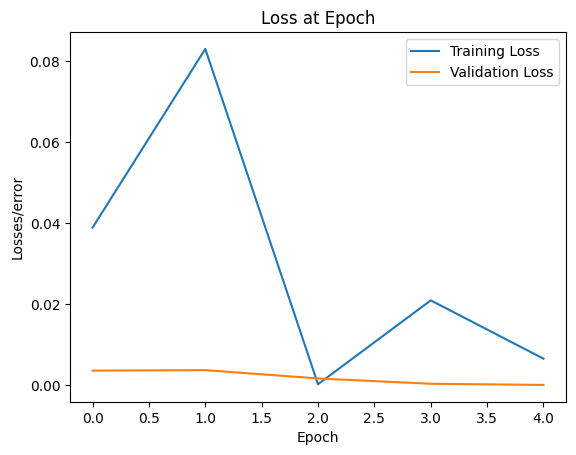

In [ ]:
#convert tensor to python list
train_losses = [tl.item() for tl in train_losses]
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Losses/error")
plt.title("Loss at Epoch")
plt.legend()

Text(0, 0.5, 'Accuracy (in %)')

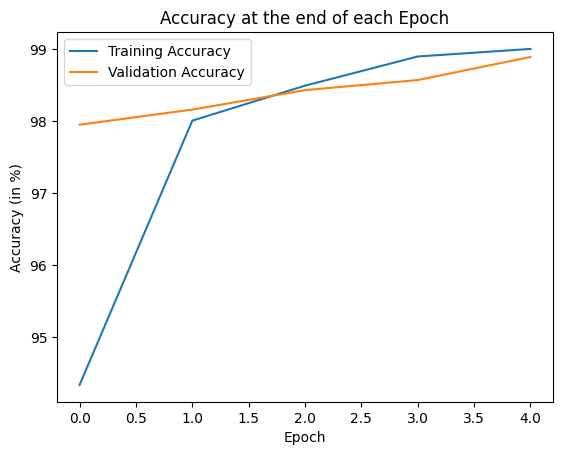

In [ ]:
#graph accuracy
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/100 for t in test_correct], label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy (in %)")

In [ ]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [ ]:
with torch.no_grad():
  correct=0
  for X_test, y_test in test_load_all:
    y_value = model(X_test)
    predicted = torch.max(y_value, 1)[1]
    correct += (predicted == y_test).sum()
acc_percent = correct.item()/len(test_data)*100
print(f"We got {correct} correct! This gives us an accuracy of {acc_percent}%.")

We got 9889 correct! This gives us an accuracy of 98.89%.


In [ ]:
test_data[4143] #tensor with image in it (shows label in the end)

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

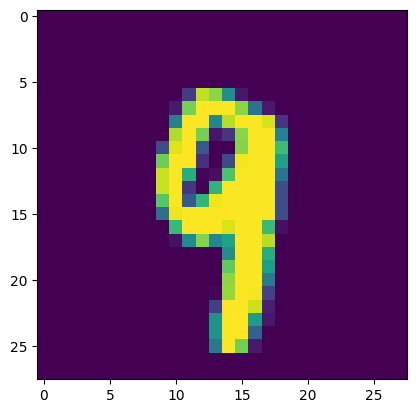

In [ ]:
plt.imshow(test_data[4143][0].reshape(28,28))

In [ ]:
#pass image thru model
model.eval()
with torch.no_grad():
  new_pred = model(test_data[4143][0].view(1,1,28,28))

In [ ]:
new_pred

tensor([[-2.0271e+01, -1.9413e+01, -2.1883e+01, -1.5903e+01, -1.2347e+01,
         -1.8901e+01, -2.6293e+01, -1.4120e+01, -1.2525e+01, -8.8214e-06]])

In [ ]:
new_pred.argmax()

tensor(9)